In this notebook, we consider the results for the filtered OU process.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 
import matplotlib.ticker as mticker
import numpy as np
import torch
import os 
import scipy
import scipy.linalg
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    # "text.latex.preamble": r"\usepackage{amsmath}" # Optional: Uncomment if needed
})

In [10]:
crossing_type = "upcrossing"  
# crossing_type = "downcrossing"
# crossing_type = "crossing"
ModelClass = formula.GaussianUpCrossingsDimless

mean_rate_method = f"{crossing_type}_mean_rate"
fano_method = f"{crossing_type}_fano_factor_CLT"

In [11]:
if crossing_type == "downcrossing":
    fano_label = r'$\mathrm{F}^\downarrow$'
elif crossing_type == "upcrossing":
    fano_label = r'$\mathrm{F}^\uparrow$'
else:
    fano_label = r'$\mathrm{F}$'

In [12]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
tau_f = 0.01   # Correlation decay parameter
sigma = 1.0 # Standard deviation (amplitude) of the process

In [13]:
num_points_kappa = 100
kappa = torch.linspace(0.01, 0.99, num_points_kappa)

num_points_psi = 100
psi = torch.linspace(0.0, 2.0, num_points_psi)

mean_rates = torch.zeros(num_points_kappa, num_points_psi)
fano_factors = torch.zeros(num_points_kappa, num_points_psi)

In [ ]:
for i in range(num_points_kappa):
    for j in range(num_points_psi):
        # u is given by psi[j]*sigma, and tau_e depends on kappa[i]
        u = psi[j] * sigma
        tau_e = tau_f / kappa[i]
        
        # Instantiate the chosen crossing model
        model = ModelClass(r_func=process.r_filtered_OU, u=u, tau=tau_e, kappa=kappa[i], sigma=sigma)
        
        # Dynamically call the appropriate methods for mean rate and Fano factor
        mean_rates[i, j] = getattr(model, mean_rate_method)()
        fano_factors[i, j] = getattr(model, fano_method)(epsilon_left=1e-5, epsilon_right=1e-5)

Info: Fano factor spans 1. Using diverging colormap.
Saving figures to: ../../figures/filtered_OU/phase_diagram_upcrossing


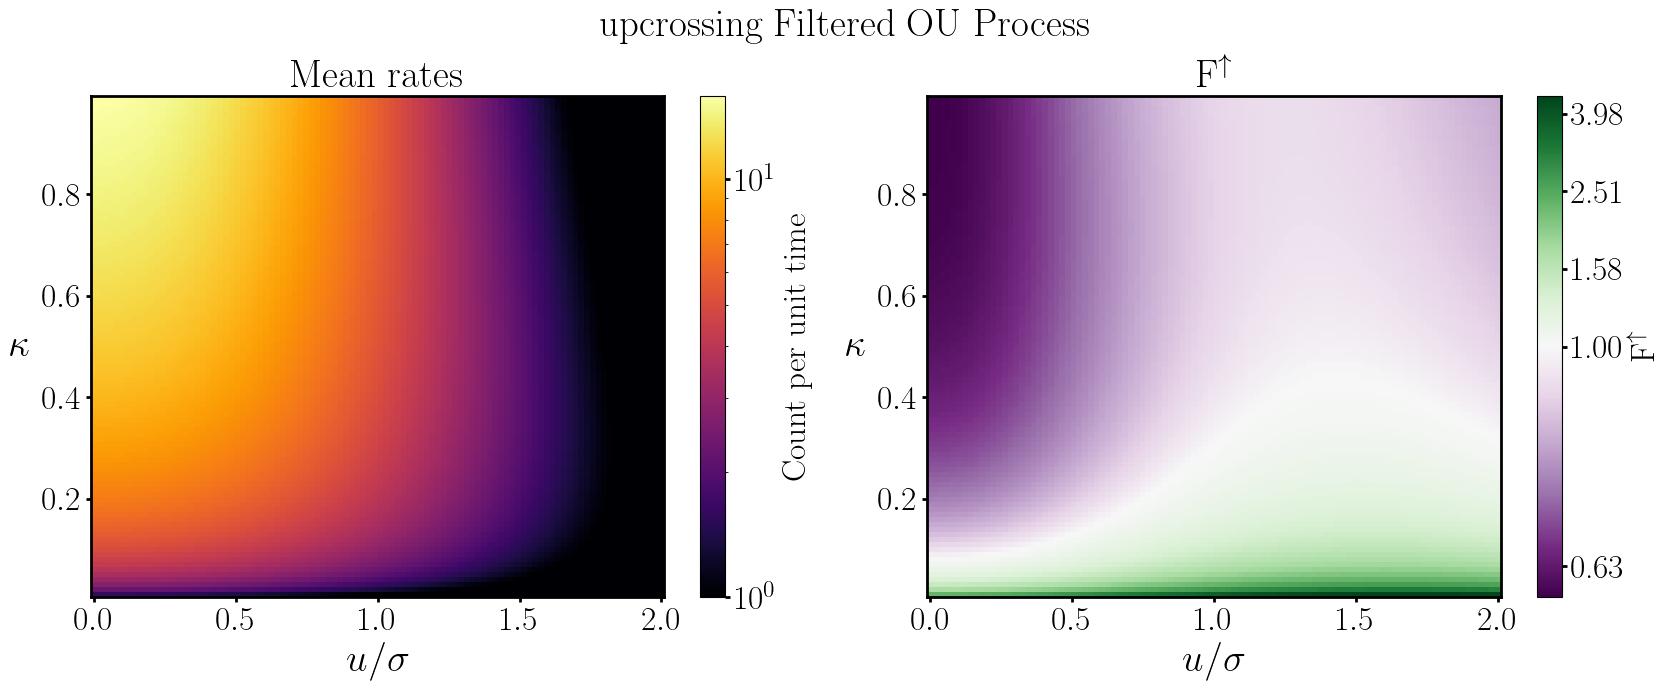

In [15]:
axis_label_fontsize = 28
tick_label_fontsize = 24
num_x_ticks = 5 # Adjusted slightly for axis ranges
num_y_ticks = 6 # Adjusted slightly for axis ranges
tick_line_width = 2.0
spine_line_width = 2.0

# Colormaps (Adopted from reference code)
cmap_mean = 'inferno'
cmap_diverging = 'PRGn'
cmap_below_1 = 'Blues_r'
cmap_above_1 = 'Reds'

# --- Fano Factor Colormap Logic (Adopted from reference code) ---
# Keep data as tensors for calculations
fano_min = fano_factors.min().item()
fano_max = fano_factors.max().item()
spans_one = (fano_min < 1.0) and (fano_max > 1.0)

fano_log = torch.log10(fano_factors)
fano_log_np = fano_log.cpu().numpy() # Convert to NumPy for min/max and plotting
log_min = fano_log_np.min()
log_max = fano_log_np.max()

# Select Colormap and Normalization based on range
if spans_one:
    print("Info: Fano factor spans 1. Using diverging colormap.")
    cmap_fano = cmap_diverging
    norm_fano = mcolors.TwoSlopeNorm(vmin=log_min, vcenter=0, vmax=log_max) # Centered at log10(1)=0
else:
    if fano_max <= 1.0:
        print("Info: Max Fano factor <= 1. Using sequential colormap (below).")
        cmap_fano = cmap_below_1
    else: # fano_min >= 1.0
        print("Info: Min Fano factor >= 1. Using sequential colormap (above).")
        cmap_fano = cmap_above_1
    norm_fano = mcolors.Normalize(vmin=log_min, vmax=log_max) # Simple log normalization


# -----------------------
# Create the figure and subplots
# Adjusted figsize slightly based on reference code
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# ---- Left subplot: Mean Rates ----
epsilon = 1 # Keep epsilon threshold
# Use torch.clip as in reference code
adjusted_mean_rates = torch.clip(mean_rates, epsilon, None)
# Use mcolors.LogNorm as in reference code
log_norm = mcolors.LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max()) # Use max from tensor

# Note: pcolormesh expects X, Y, C. Here X=psi, Y=kappa
pc0 = axes[0].pcolormesh(psi, kappa, adjusted_mean_rates, shading='auto', # Use tensors directly
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
# Apply new styling (from reference code)
cbar0.set_label("Count per unit time", fontsize=tick_label_fontsize)
cbar0.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new styling (from reference code)
axes[0].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
# Updated y-axis label for kappa
axes[0].set_ylabel(r'$\kappa$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=15) # Adjusted padding
axes[0].set_title('Mean rates', fontsize=axis_label_fontsize)

# Apply new tick locator and styling (from reference code)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[0].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[0].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width (from reference code)
axes[0].spines['top'].set_linewidth(spine_line_width)
axes[0].spines['right'].set_linewidth(spine_line_width)
axes[0].spines['bottom'].set_linewidth(spine_line_width)
axes[0].spines['left'].set_linewidth(spine_line_width)


# ---- Right subplot: Fano Factors ----
# Use fano_log_np, cmap_fano and norm_fano determined by logic above
# Ensure correct axes: X=psi, Y=kappa
pc1 = axes[1].pcolormesh(psi, kappa, fano_log_np, shading='auto', # Use numpy array for C
                         cmap=cmap_fano, norm=norm_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
# Apply new styling (from reference code)
cbar1.set_label(fano_label, fontsize=tick_label_fontsize) # Use defined fano_label
cbar1.ax.tick_params(labelsize=tick_label_fontsize, width=tick_line_width)

# Keep original log tick formatter (from reference code)
def log_tick_formatter(x, pos):
    return f"{10**x:.2f}"
cbar1.formatter = mticker.FuncFormatter(log_tick_formatter)
cbar1.update_ticks()

# Apply new styling (from reference code)
axes[1].set_xlabel(r'$u/\sigma$', fontsize=axis_label_fontsize)
# Updated y-axis label for kappa
axes[1].set_ylabel(r'$\kappa$', fontsize=axis_label_fontsize, rotation=0, va='center', labelpad=15) # Adjusted padding
axes[1].set_title(fano_label, fontsize=axis_label_fontsize) # Use defined fano_label

# Apply new tick locator and styling (from reference code)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(num_x_ticks))
axes[1].yaxis.set_major_locator(plt.MaxNLocator(num_y_ticks))
axes[1].tick_params(axis='both', which='major', labelsize=tick_label_fontsize, width=tick_line_width)

# Apply new spine width (from reference code)
axes[1].spines['top'].set_linewidth(spine_line_width)
axes[1].spines['right'].set_linewidth(spine_line_width)
axes[1].spines['bottom'].set_linewidth(spine_line_width)
axes[1].spines['left'].set_linewidth(spine_line_width)

# Apply new font size to suptitle and update process name
fig.suptitle(f"{crossing_type} Filtered OU Process", fontsize=axis_label_fontsize) # Updated process name

plt.tight_layout()

# --- Save the figure (Adopted from reference code) ---
# Adapt folder location for the filtered OU process
folder_loc = f'../../figures/filtered_OU/'
os.makedirs(folder_loc, exist_ok=True) # Create folder if it doesn't exist
file_name = f'phase_diagram_{crossing_type}'
file_save_path = os.path.join(folder_loc, file_name)

print(f"Saving figures to: {file_save_path}")
plt.savefig(f'{file_save_path}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.svg', format='svg', bbox_inches='tight', dpi=300)
plt.savefig(f'{file_save_path}.eps', format='eps', bbox_inches='tight', dpi=300)

plt.show()

In [21]:
kappa = 0.8
tau_e = tau_f / kappa
u = 0.5 * sigma
model = ModelClass(r_func=process.r_filtered_OU, u=u, tau=tau_e, kappa=kappa, sigma=sigma)
print(getattr(model, fano_method)(epsilon_left=1e-2, epsilon_right=1e-5))
print(getattr(model, mean_rate_method)())

tensor(0.7160)
tensor(11.3671)
